In [1]:
!pip install imbalance-metrics smogn

In [2]:
!pip install ImbalancedLearningRegression


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.2/77.2 kB 1.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator
from smogn import phi, phi_ctrl_pts
from sklearn.model_selection import KFold
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from scipy.spatial import distance
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    BaggingRegressor
)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.linear_model import (
    ARDRegression,
    SGDRegressor,
    PassiveAggressiveRegressor
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from smogn import smoter
import ImbalancedLearningRegression as iblr

### MAE

In [4]:
import pandas as pd

# Carregar datasets
ro = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_RO_07_repeat.csv')
gn = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_GN_07_repeated.csv')
dist_ro = pd.read_csv('/content/drive/MyDrive/TCC/Distance_RO.csv')
dist_gn = pd.read_csv('/content/drive/MyDrive/TCC/Distance_GN.csv')

# Padronizar nomes das versões
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'RO': 'GN',
    'Hardness-RO': 'Hardness-GN'  # caso tenha esse nome
})

# Unir tudo
df = pd.concat([ro, dist_ro, gn, dist_gn], ignore_index=True)

# Função para decidir o vencedor de cada Dataset+Model
def vencedor(grupo):
    linha_min = grupo.loc[grupo["MAE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'Distance-RO': int(vencedor == 'Distance-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
        'Distance-GN': int(vencedor == 'Distance-GN'),
    })

# Calcular vencedor por dataset + modelo
vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)

# Somar as vitórias por modelo
tabela_final = vitorias.groupby("Model").sum().reset_index()

linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "Distance-RO": [tabela_final["Distance-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()],
    "Distance-GN": [tabela_final["Distance-GN"].sum()]
})

# Concatenar no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)



/tmp/ipython-input-3780469906.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)


In [5]:
tabela_final

,Model,Original,RO,Hardness-RO,Distance-RO,GN,Hardness-GN,Distance-GN
0,BAGGING,5,5,9,3,0,6,1
1,NNET,4,6,10,4,1,4,0
2,RF,6,6,8,2,0,6,1
3,SVR,11,1,11,4,0,1,1
4,XGB,6,6,10,4,0,3,0
5,Total,32,24,48,17,1,20,3


## MSE

In [8]:
import pandas as pd

# Carregar datasets
ro = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_RO_07_repeat.csv')
gn = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_GN_07_repeated.csv')
dist_ro = pd.read_csv('/content/drive/MyDrive/TCC/Distance_RO.csv')
dist_gn = pd.read_csv('/content/drive/MyDrive/TCC/Distance_GN.csv')

# Padronizar nomes das versões
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'RO': 'GN',
    'Hardness-RO': 'Hardness-GN'  # caso tenha esse nome
})

# Unir tudo
df = pd.concat([ro,dist_ro, gn,dist_gn], ignore_index=True)

# Função para decidir o vencedor de cada Dataset+Model
def vencedor(grupo):
    linha_min = grupo.loc[grupo["MSE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'Distance-RO': int(vencedor == 'Distance-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
        'Distance-GN': int(vencedor == 'Distance-GN'),
    })

# Calcular vencedor por dataset + modelo
vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)

# Somar as vitórias por modelo
tabela_final = vitorias.groupby("Model").sum().reset_index()

linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "Distance-RO": [tabela_final["Distance-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()],
    "Distance-GN": [tabela_final["Distance-GN"].sum()],
})

# Concatenar no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)



/tmp/ipython-input-3114878992.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)


In [9]:
tabela_final

,Model,Original,RO,Hardness-RO,Distance-RO,GN,Hardness-GN,Distance-GN
0,BAGGING,8,4,6,5,0,5,1
1,NNET,7,5,8,4,1,4,0
2,RF,6,5,9,4,0,5,0
3,SVR,7,1,5,9,2,3,2
4,XGB,6,6,10,4,0,3,0
5,Total,34,21,38,26,3,20,3


# Rodando balanceamento para o bimodal

In [ ]:
np.random.seed(42)

n = 3000

X = np.random.normal(size=(n, 2))
x1, x2 = X[:, 0], X[:, 1]

group = np.random.choice([0, 1], size=n)

offset_0 = -4
offset_1 =  6

y = (
    (group == 0) * (offset_0 + 1.5*x1 + 0.5*x2) +
    (group == 1) * (offset_1 + 0.8*x1 + 1.2*x2)
)

df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y
df["group"] = group

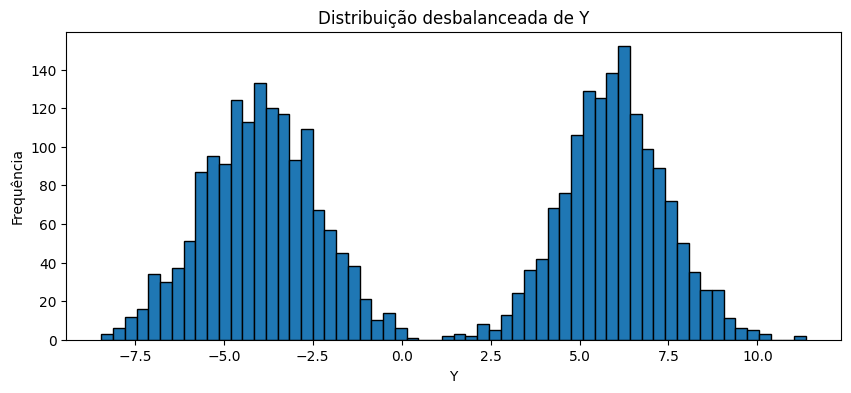

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(y, bins=60, edgecolor="black")
plt.title("Distribuição desbalanceada de Y")
plt.xlabel("Y")
plt.ylabel("Frequência")
plt.show()

In [ ]:
models_pool = [
    SVR(),
    RandomForestRegressor(n_estimators=100, random_state=42),
    DecisionTreeRegressor(random_state=42),
    MLPRegressor(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42),
    BaggingRegressor(random_state=42),
    XGBRegressor(n_estimators=100, random_state=42)
]

In [ ]:
def instance_hardness_regression(X, y, models=models_pool, distance='l1', n_splits=10, logs=False, gamma_fixo = False, fator_divisao_gamma = 1):
    n = len(y)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    if gamma_fixo:
      gamma = 1
    else:
      ### Justamente o que diz no artigo, que é a media do target elevado a 2
      gamma = np.mean(y**2) / fator_divisao_gamma #### Gamma menor -> Maior sensibilidade a erros, deixando o valor final de IG mais proximo de 1 ( Por padrão é np.mean(y**2))

    preds_pool = np.zeros((n, len(models)))

    ### Cross-validation ###
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        if logs:
          print(f"Iniciando fold {fold_idx}/{n_splits}...")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]

        ### ADICIONAR OS TIPOS DE BALANCEAMENTO NO X_TRAIN AQUI
        for j, model in enumerate(models):
            if logs:
              print(f"Treinando modelo {j+1}/{len(models)}: {type(model).__name__} ...")
            clone_model = type(model)(**model.get_params())
            clone_model.fit(X_train, y_train)
            preds_pool[test_idx, j] = clone_model.predict(X_test)

    if distance == 'l1':
        dists = np.abs(y.reshape(-1, 1) - preds_pool)
    elif distance == 'l2':
        dists = (y.reshape(-1, 1) - preds_pool)**2
    else:
        raise ValueError("Use 'l1' ou 'l2'.")

    exp_term = np.exp(-dists / gamma)
    ih_values = 1 - np.mean(exp_term, axis=1) ### Isso equivale a divisão por |L|

    return ih_values

In [ ]:
y = df['y'].values
X = df.drop(columns=['y']).values

In [ ]:
ih_scores = instance_hardness_regression(X, y)

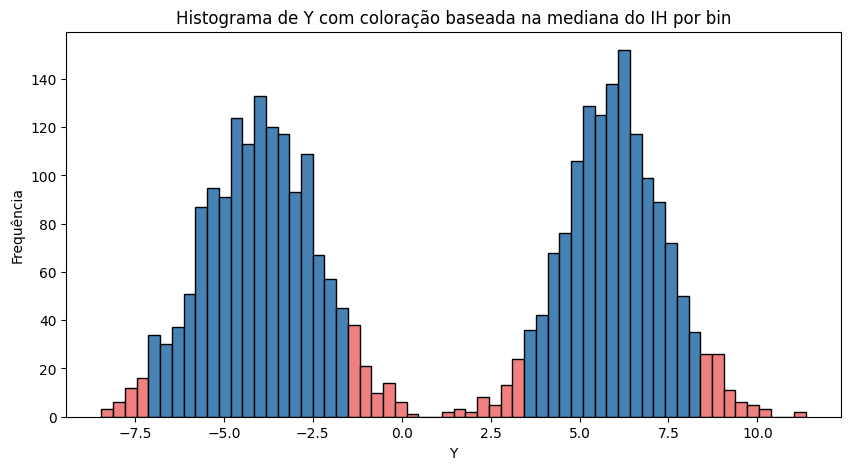

In [ ]:
ys = y
ihs = ih_scores

bins = 60

counts, bin_edges = np.histogram(ys, bins=bins)

global_threshold  = np.quantile(ihs, 0.8)

plt.figure(figsize=(10,5))

colors = []

bin_medians = []


for i in range(len(bin_edges)-1):
    left = bin_edges[i]
    right = bin_edges[i+1]

    mask = (ys >= left) & (ys < right)
    ih_bin = ihs[mask]

    if len(ih_bin) > 0:
        med_bin = np.median(ih_bin)
    else:
        med_bin = 0

    bin_medians.append(med_bin)

    if med_bin > global_threshold :
        colors.append("lightcoral")
    else:
        colors.append("steelblue")


for i in range(len(counts)):
    plt.bar(
        (bin_edges[i] + bin_edges[i+1]) / 2,
        counts[i],
        width=(bin_edges[i+1] - bin_edges[i]),
        color=colors[i],
        edgecolor="black"
    )

plt.title("Histograma de Y com coloração baseada na mediana do IH por bin")
plt.xlabel("Y")
plt.ylabel("Frequência")

plt.show()

## RO

In [ ]:
## load dependencies - third party
import numpy as np
import pandas as pd
import random as rd
from tqdm import tqdm


## generate synthetic observations
def over_sampling_ro(

    ## arguments / inputs
    data,       ## training set
    index,      ## index of input data
    perc,       ## over / under sampling
    replace,    ## sampling replacement (bool)

    ):

    """
    generates synthetic observations and is the primary function underlying the
    over-sampling technique utilized in the higher main function 'ro()', the
    4 step procedure for generating synthetic observations is:

    1) pre-processing: temporarily removes features without variation, label
    encodes nominal / categorical features, and subsets the training set into
    two data sets by data type: numeric / continuous, and nominal / categorical

    2) over-sampling: RO, which random choose samples from the original samples

    3) post processing: restores original values for label encoded features,
    reintroduces constant features previously removed, converts any interpolated
    negative values to zero in the case of non-negative features

    returns a pandas dataframe containing synthetic observations of the training
    set which are then returned to the higher main function 'ro()'

    ref:

    Branco, P., Torgo, L., Ribeiro, R. (2017).
    SMOGN: A Pre-Processing Approach for Imbalanced Regression.
    Proceedings of Machine Learning Research, 74:36-50.
    http://proceedings.mlr.press/v74/branco17a/branco17a.pdf.

    Branco, P., Ribeiro, R., Torgo, L. (2017).
    Package 'UBL'. The Comprehensive R Archive Network (CRAN).
    https://cran.r-project.org/web/packages/UBL/UBL.pdf.

    Branco, P., Torgo, L., & Ribeiro, R. P. (2019).
    Pre-processing approaches for imbalanced distributions in regression.
    Neurocomputing, 343, 76-99.
    https://www.sciencedirect.com/science/article/abs/pii/S0925231219301638

    Kunz, N., (2019). SMOGN.
    https://github.com/nickkunz/smogn
    """

    ## subset original dataframe by bump classification index
    data = data.iloc[index]

    ## store dimensions of data subset
    n = len(data)
    d = len(data.columns)

    ## store original data types
    feat_dtypes_orig = [None] * d

    for j in range(d):
        feat_dtypes_orig[j] = data.iloc[:, j].dtype

    ## find non-negative numeric features
    feat_non_neg = []
    num_dtypes = ["int64", "float64"]

    for j in range(d):
        if data.iloc[:, j].dtype in num_dtypes and any(data.iloc[:, j] > 0):
            feat_non_neg.append(j)

    ## find features without variation (constant features)
    feat_const = data.columns[data.nunique() == 1]

    ## temporarily remove constant features
    if len(feat_const) > 0:

        ## create copy of orignal data and omit constant features
        data_orig = data.copy()
        data = data.drop(data.columns[feat_const], axis = 1)

        ## store list of features with variation
        feat_var = list(data.columns.values)

        ## reindex features with variation
        for i in range(d - len(feat_const)):
            data.rename(columns = {
                data.columns[i]: i
                }, inplace = True)

        ## store new dimension of feature space
        d = len(data.columns)

    ## create copy of data containing variation
    data_var = data.copy()

    ## create global feature list by column index
    feat_list = list(data.columns.values)

    ## create nominal feature list and
    ## label encode nominal / categorical features
    ## (strictly label encode, not one hot encode)
    feat_list_nom = []
    nom_dtypes = ["object", "bool", "datetime64"]

    # Unknown warning, may be handled later
    pd.options.mode.chained_assignment = None

    for j in range(d):
        if data.dtypes[j] in nom_dtypes:
            feat_list_nom.append(j)
            data.iloc[:, j] = pd.Categorical(pd.factorize(
                data.iloc[:, j])[0])

    data = data.apply(pd.to_numeric)

    ## create numeric feature list
    feat_list_num = list(set(feat_list) - set(feat_list_nom))

    ## calculate ranges for numeric / continuous features
    ## (includes label encoded features)
    feat_ranges = list(np.repeat(1, d))

    if len(feat_list_nom) > 0:
        for j in feat_list_num:
            feat_ranges[j] = max(data.iloc[:, j]) - min(data.iloc[:, j])
    else:
        for j in range(d):
            feat_ranges[j] = max(data.iloc[:, j]) - min(data.iloc[:, j])

    ## subset feature ranges to include only numeric features
    ## (excludes label encoded features)
    feat_ranges_num = [feat_ranges[i] for i in feat_list_num]

    ## subset data by either numeric / continuous or nominal / categorical
    data_num = data.iloc[:, feat_list_num]
    data_nom = data.iloc[:, feat_list_nom]

    ## get number of features for each data type
    feat_count_num = len(feat_list_num)
    feat_count_nom = len(feat_list_nom)


    ## number of new synthetic observations for each rare observation
    x_synth = int(perc - 1)

    ## total number of new synthetic observations to generate
    n_synth = int(n * (perc - 1 - x_synth))

    ## randomly index data by the number of new synthetic observations
    r_index = np.random.choice(
        a = tuple(range(0, n)),
        size = x_synth * n + n_synth if replace else n_synth,
        replace = replace,
        p = None
    )

    ## create null matrix to store new synthetic observations
    synth_matrix = np.ndarray(shape = ((x_synth * n + n_synth), d))

    # added
    ## store data in the synthetic matrix, data indices are chosen randomly above
    count = 0
    for i in tqdm(r_index, ascii = True, desc = "r_index"):
        for attr in range(d):
            synth_matrix[count, attr] = (data.iloc[i, attr])
        count = count + 1
    ## if the number of random chosen samples is greater than the number of samples，
    ## and replace = False,
    ## simply duplicate x_synth times the original samples
    if not replace:
        for i in tqdm(range(x_synth * n), ascii = True, desc = "duplicating_the_same_samples"):
            for attr in range(d):
                synth_matrix[count, attr] = (data.iloc[i % n, attr])
            count = count + 1


    ## convert synthetic matrix to dataframe
    data_new = pd.DataFrame(synth_matrix)

    ## synthetic data quality check
    if sum(data_new.isnull().sum()) > 0:
        raise ValueError("oops! synthetic data contains missing values")

    ## replace label encoded values with original values
    for j in feat_list_nom:
        code_list = data.iloc[:, j].unique()
        cat_list = data_var.iloc[:, j].unique()

        for x in code_list:
            data_new.iloc[:, j] = data_new.iloc[:, j].replace(x, cat_list[x])

    ## reintroduce constant features previously removed
    if len(feat_const) > 0:
        data_new.columns = feat_var

        for j in range(len(feat_const)):
            data_new.insert(
                loc = int(feat_const[j]),
                column = feat_const[j],
                value = np.repeat(
                    data_orig.iloc[0, feat_const[j]],
                    len(synth_matrix))
            )

    ## convert negative values to zero in non-negative features
    for j in feat_non_neg:
        # data_new.iloc[:, j][data_new.iloc[:, j] < 0] = 0
        data_new.iloc[:, j] = data_new.iloc[:, j].clip(lower = 0)

    ## return over-sampling results dataframe
    return data_new

In [ ]:
def apply_ro_ih(
    data,
    y,
    samp_method="balance",
    drop_na_col=True,
    drop_na_row=True,
    replace=True,
    manual_perc=False,
    perc_o=-1,
    rel_thres=0.5,
    rel_method="auto",
    rel_xtrm_type="both",
    rel_coef=1.5,
    rel_ctrl_pts_rg=None
):
    """
    Versão do ro() mantendo todo o fluxo original, mas substituindo a etapa
    de phi(y) por Instance Hardness (IH) calculado pela função
    instance_hardness_regression. Basta passar `ih_models` (lista de modelos).
    """

    ## PRE-PROCESSAMENTO (IGUAL AO ORIGINAL)
    if bool(drop_na_col):
        data = data.dropna(axis=1)

    if bool(drop_na_row):
        data = data.dropna(axis=0)

    if data.isnull().values.any():
        raise ValueError("cannot proceed: data cannot contain NaN values")

    if not isinstance(y, str):
        raise ValueError("y must be a string")

    if y not in data.columns:
        raise ValueError("y must be a header in dataframe")

    if samp_method not in ["balance", "extreme"]:
        raise ValueError("samp_method must be 'balance' or 'extreme'")

    if manual_perc:
        if perc_o == -1:
            raise ValueError("require percentage of over-sampling")
        if perc_o <= 0:
            raise ValueError("percentage must be positive real")

    if rel_thres <= 0 or rel_thres > 1:
        raise ValueError("rel_thres must be 0 < R < 1")
    n = len(data)
    d = len(data.columns)

    feat_dtypes_orig = [data.iloc[:, j].dtype for j in range(d)]

    # SALVAR cópia do índice original (usado para alinhar IH)
    original_index = data.index.copy()

    # antes de mover y, extraio X e y originais para calcular IH
    X_for_ih = data.drop(columns=[y]).copy()
    y_for_ih = data[y].copy()

    # determinar coluna y e mover para a última posição (mantendo fluxo original)
    y_col = data.columns.get_loc(y)
    if y_col < d - 1:
        cols = list(range(d))
        cols[y_col], cols[d - 1] = cols[d - 1], cols[y_col]
        data = data[data.columns[cols]]

    # continuar com a codificação de colunas por índice
    feat_names = list(data.columns)
    data.columns = range(d)

    # criar y_sorted (séria com índices do dataframe original)
    y_df = pd.DataFrame(data[d - 1])
    y_sort = y_df.sort_values(by=d - 1)
    y_sort_series = y_sort[d - 1]  # Series ordenada com índices originais

    # -----------------------------
    # calcular IH usando a função fornecida (no dataset original)
    # -----------------------------
    # transformar X_for_ih e y_for_ih para numpy
    X_np = X_for_ih.to_numpy()
    y_np = y_for_ih.to_numpy().reshape(-1)

    ih_original = instance_hardness_regression(
        X_np,
        y_np
    )

    # criar Series de IH indexada pelo índice original do dataframe
    ih_series = pd.Series(ih_original, index=original_index)

    # reordenar ih para acompanhar y_sort (usando os índices ordenados de y_sort)
    y_ih = ih_series.loc[y_sort_series.index].values

    # validações análogas às do phi
    if all(i == 0 for i in y_ih):
        raise ValueError("redefine IH relevance function: all points are 0")

    if all(i == 1 for i in y_ih):
        raise ValueError("redefine IH relevance function: all points are 1")

    # ---------------------------------------------------------
    # determinar os bumps (raros vs normais) usando top 20% IH
    # ---------------------------------------------------------
    bumps = [0]
    # threshold dinâmico: percentil 80 (top 20% IH)
    dynamic_thres = np.percentile(y_ih, 50)

    for i in range(len(y_ih) - 1):
        if ((y_ih[i] >= dynamic_thres and y_ih[i + 1] < dynamic_thres) or
            (y_ih[i] < dynamic_thres and y_ih[i + 1] >= dynamic_thres)):
            bumps.append(i + 1)

    bumps.append(n)

    n_bumps = len(bumps) - 1

    b_index = {}
    for i in range(n_bumps):
        # aqui usamos y_sort (Series) com slicing para preservar índices originais,
        # como no seu código original.
        b_index.update({i: y_sort_series[bumps[i]:bumps[i + 1]]})

    # cálculo de s_perc idêntico ao original
    b = round(n / n_bumps)
    s_perc = []
    scale = []
    obj = []

    if samp_method == "balance":
        for i in b_index:
            s_perc.append(b / len(b_index[i]))

    if samp_method == "extreme":
        for i in b_index:
            scale.append(b ** 2 / len(b_index[i]))
        scale = n_bumps * b / sum(scale)

        for i in b_index:
            obj.append(round(b ** 2 / len(b_index[i]) * scale, 2))
            s_perc.append(round(obj[i] / len(b_index[i]), 1))

    data_new = pd.DataFrame()

    for i in range(n_bumps):

        if s_perc[i] == 1:
            # b_index[i] é uma Series (y values) com índices originais
            data_new = pd.concat(
                [data.iloc[b_index[i].index], data_new], ignore_index=True
            )

        if s_perc[i] > 1:

            synth_obs = over_sampling_ro(
                data=data,
                index=list(b_index[i].index),
                perc=s_perc[i] if not manual_perc else perc_o + 1,
                replace=replace
            )

            data_new = pd.concat([synth_obs, data_new], ignore_index=True)

            original_obs = data.iloc[list(b_index[i].index)]
            data_new = pd.concat([original_obs, data_new], ignore_index=True)

        if s_perc[i] < 1:
            original_obs = data.iloc[list(b_index[i].index)]
            data_new = pd.concat([original_obs, data_new], ignore_index=True)

    # restaurar nomes das colunas originais
    data_new.columns = feat_names

    # restaurar posição original de y, se necessário
    if y_col < d - 1:
        cols = list(range(d))
        cols[y_col], cols[d - 1] = cols[d - 1], cols[y_col]
        data_new = data_new[data_new.columns[cols]]

    # restaurar tipos originais
    for j in range(d):
        data_new.iloc[:, j] = data_new.iloc[:, j].astype(feat_dtypes_orig[j])

    return data_new

In [ ]:
def apply_iblr_ro(data, target, method="balance", rel_thres=0.8):
    """
    Wrapper do IBLR-RO

    data: DataFrame completo (X + y)
    target: nome da coluna target
    method: método de amostragem (ex: "balance", "random"...)
    rel_thres: limiar de relevância
    """
    try:
        data = data.copy()
        data.columns = data.columns.astype(str)  # garante compatibilidade

        new_data = iblr.ro(
            data=data,
            y=str(target),
            samp_method=method,
            rel_thres=rel_thres
        )
        return new_data

    except Exception as e:
        print("⚠️ IBLR-RO falhou:", e)
        return data.copy()


def apply_iblr_gn(data, target, method="balance", pert=0.1, rel_thres=0.8):
    """
    Wrapper do IBLR-GN

    data: DataFrame completo (X + y)
    target: nome da coluna target
    method: método de amostragem (ex: "balance", "random"...)
    pert: nível de perturbação
    rel_thres: limiar de relevância
    """
    try:
        data = data.copy()
        data.columns = data.columns.astype(str)  # garante compatibilidade

        new_data = iblr.gn(
            data=data,
            y=str(target),
            samp_method=method,
            pert=pert,
            rel_thres=rel_thres
        )
        return new_data

    except Exception as e:
        print("⚠️ IBLR-GN falhou:", e)
        return data.copy()



In [ ]:

def evaluate_model(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # MSE
    mse = mean_squared_error(y_test, y_pred)

    # mae
    mae = mean_absolute_error(y_test, y_pred)

    return mse, mae


In [ ]:
models = {
    "SVR": SVR(),  # não possui random_state
    "NNET":MLPRegressor(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42),
    "XGB":XGBRegressor(n_estimators=100, random_state=42),
    "RF":  RandomForestRegressor(n_estimators=100, random_state=42),
    "BAGGING": BaggingRegressor(random_state=42)
}

In [ ]:

datasets = {
    "bimodal": {"data": df, "target": "y"}
}

In [ ]:
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

results = []

for name, info in datasets.items():
    df = info["data"].copy()
    target = info["target"]

    print(f"\nProcessando: {name}")

    X = df.drop(columns=[target])
    y = df[target]

    # Loop RepeatedKFold
    for fold_id, (train_idx, test_idx) in enumerate(rkf.split(X)):
        repeat = fold_id // 5 + 1
        fold = fold_id % 5 + 1

        print(f"  Repetição {repeat}/2 - Fold {fold}/5")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        base_train = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)

        # Oversampling dentro do fold
        try:
            train_smogn = apply_iblr_ro(base_train, target)
        except Exception as e:
            print(f"⚠️ RO falhou no fold {fold} da repetição {repeat}: {e}")
            train_smogn = base_train.copy()

        train_hard = apply_ro_ih(base_train, target)

        versions = {
            "Original": base_train,
            "RO": train_smogn,
            "Hardness-RO": train_hard
        }

        for model_name, model in models.items():
            for version_name, train_data in versions.items():

                Xtr = train_data.drop(columns=[target])
                ytr = train_data[target]

                Xts = X_test
                yts = y_test

                # Ajuste e predição
                model.fit(Xtr, ytr)
                y_pred = model.predict(Xts)

                # Cálculo das métricas
                mse = mean_squared_error(yts, y_pred)
                mae = mean_absolute_error(yts, y_pred)

                results.append({
                    "Dataset": name,
                    "Repeticao": repeat,
                    "Fold": fold,
                    "Model": model_name,
                    "Versao": version_name,
                    "MSE": mse,
                    "MAE": mae,
                    "y_pred": y_pred.tolist(),   # <<<<<<<< AQUI EXPORTA O Y PREDITO
                    "y_true": yts.tolist()        # (opcional mas recomendado)
                })



Processando: bimodal
  Repetição 1/2 - Fold 1/5
⚠️ IBLR-RO falhou: redefine phi relevance function: all points are 1


r_index: 100%|##########| 1/1 [00:00<00:00, 6668.21it/s]


  Repetição 1/2 - Fold 2/5
⚠️ IBLR-RO falhou: redefine phi relevance function: all points are 1


r_index: 100%|##########| 1/1 [00:00<00:00, 7557.30it/s]


  Repetição 1/2 - Fold 3/5
⚠️ IBLR-RO falhou: redefine phi relevance function: all points are 1


...

r_index: 100%|##########| 1/1 [00:00<00:00, 8019.70it/s]


  Repetição 2/2 - Fold 4/5
⚠️ IBLR-RO falhou: redefine phi relevance function: all points are 1


r_index: 100%|##########| 1/1 [00:00<00:00, 9709.04it/s]


  Repetição 2/2 - Fold 5/5
⚠️ IBLR-RO falhou: redefine phi relevance function: all points are 1


r_index: 100%|##########| 1/1 [00:00<00:00, 11096.04it/s]


In [ ]:
results_df = pd.DataFrame(results)
results_df.head(50)
results_df_ro_bi = results_df.copy()

In [ ]:
# Definir a ordem desejada
ordem_versoes = ["Original", "RO", "Hardness-RO"]

results_df["Versao"] = pd.Categorical(
    results_df["Versao"],
    categories=ordem_versoes,
    ordered=True
)

mse_por_modelo = (
    results_df
    .groupby(["Dataset", "Model", "Versao"], as_index=False)
    .agg(
        MSE_medio=("MSE", "mean"),
        MAE_medio=("MAE", "mean")
        )
    .sort_values(["Dataset", "Model", "Versao"])
)

mse_por_modelo.head(60)

/tmp/ipython-input-4070163773.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Model", "Versao"], as_index=False)


,Dataset,Model,Versao,MSE_medio,MAE_medio
0,bimodal,BAGGING,Original,0.012440,0.059385
1,bimodal,BAGGING,RO,0.012440,0.059385
2,bimodal,BAGGING,Hardness-RO,0.012647,0.059218
3,bimodal,NNET,Original,0.004613,0.046728
4,bimodal,NNET,RO,0.004613,0.046728
5,bimodal,NNET,Hardness-RO,0.003888,0.042320
6,bimodal,RF,Original,0.010334,0.047496
7,bimodal,RF,RO,0.010334,0.047496
8,bimodal,RF,Hardness-RO,0.010265,0.048039
9,bimodal,SVR,Original,0.115544,0.118289


### MSE

In [ ]:
import pandas as pd

# ===============================
# 1. Ordenar versões corretamente
# ===============================

ordem_versoes = ["Original", "RO", "Hardness-RO"]

results_df["Versao"] = pd.Categorical(
    results_df["Versao"],
    categories=ordem_versoes,
    ordered=True
)

# ===============================
# 2. Agregar MSE médio por fold
# ===============================

mse_por_modelo = (
    results_df
    .groupby(["Dataset", "Model", "Versao"], as_index=False)
    .agg(MSE_medio=("MSE", "mean"))
    .sort_values(["Dataset", "Model", "Versao"])
)

print("\n📊 MSE médio por versão:")
print(mse_por_modelo)

# ===============================
# 3. Comparação entre RO e Hardness
# ===============================

# Filtrar somente RO e Hardness-RO
comp = mse_por_modelo[
    mse_por_modelo["Versao"].isin(["Original", "Hardness-RO"])
]

# Pivot: transformar em colunas RO e Hardness-RO
pivot = comp.pivot(
    index=["Dataset", "Model"],
    columns="Versao",
    values="MSE_medio"
).reset_index()

print("\n📌 Comparação direta:")
print(pivot)

# ===============================
# 4. Quem foi melhor?
# ===============================

pivot["Hardness_melhor_que_Original"] = pivot["Hardness-RO"] < pivot["Original"]
pivot["Original_melhor_que_Hardness"] = pivot["Original"] < pivot["Hardness-RO"]
pivot["Empate"] = pivot["Original"] == pivot["Hardness-RO"]

# ===============================
# 5. Contagem geral
# ===============================

total_hardness = pivot["Hardness_melhor_que_Original"].sum()
total_ro = pivot["Original_melhor_que_Hardness"].sum()
empates = pivot["Empate"].sum()

print(f"\n🏆 RESULTADO GERAL:")
print(f"Hardness-RO foi melhor em {total_hardness} pares (dataset, modelo)")
print(f"Original foi melhor em {total_ro} pares (dataset, modelo)")
print(f"Houve {empates} empates")

# ===============================
# 6. Contagem por dataset
# ===============================

hardness_por_dataset = (
    pivot[pivot["Hardness_melhor_que_Original"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_Hardness")
)

ro_por_dataset = (
    pivot[pivot["Original_melhor_que_Hardness"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_Original")
)

print("\n📌 Hardness-RO melhor que Original por dataset:")
print(hardness_por_dataset)

print("\n📌 Original melhor que Hardness-RO por dataset:")
print(ro_por_dataset)

# ===============================
# 7. Frases finais (estilo artigo)
# ===============================

datasets_hardness = hardness_por_dataset["Dataset"].nunique()
datasets_ro = ro_por_dataset["Dataset"].nunique()

modelos_hardness = hardness_por_dataset["Modelos_ganhos_Hardness"]



📊 MSE médio por versão:
    Dataset    Model       Versao  MSE_medio
0   bimodal  BAGGING     Original   0.012440
1   bimodal  BAGGING           RO   0.012440
2   bimodal  BAGGING  Hardness-RO   0.012647
3   bimodal     NNET     Original   0.004613
4   bimodal     NNET           RO   0.004613
5   bimodal     NNET  Hardness-RO   0.003888
6   bimodal       RF     Original   0.010334
7   bimodal       RF           RO   0.010334
8   bimodal       RF  Hardness-RO   0.010265
9   bimodal      SVR     Original   0.115544
10  bimodal      SVR           RO   0.115544
11  bimodal      SVR  Hardness-RO   0.109508
12  bimodal      XGB     Original   0.010646
13  bimodal      XGB           RO   0.010646
14  bimodal      XGB  Hardness-RO   0.010783

📌 Comparação direta:
Versao  Dataset    Model  Original  Hardness-RO
0       bimodal  BAGGING  0.012440     0.012647
1       bimodal     NNET  0.004613     0.003888
2       bimodal       RF  0.010334     0.010265
3       bimodal      SVR  0.115544     0.

/tmp/ipython-input-1769328054.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Model", "Versao"], as_index=False)


### MAE

In [ ]:
import pandas as pd

# ===============================
# 1. Ordenar versões corretamente
# ===============================

ordem_versoes = ["Original", "RO", "Hardness-RO"]

results_df["Versao"] = pd.Categorical(
    results_df["Versao"],
    categories=ordem_versoes,
    ordered=True
)

# ===============================
# 2. Agregar MAE médio por fold
# ===============================

MAE_por_modelo = (
    results_df
    .groupby(["Dataset", "Model", "Versao"], as_index=False)
    .agg(MAE_medio=("MAE", "mean"))
    .sort_values(["Dataset", "Model", "Versao"])
)

print("\n📊 MAE médio por versão:")
print(MAE_por_modelo)

# ===============================
# 3. Comparação entre RO e Hardness
# ===============================

# Filtrar somente RO e Hardness-RO
comp = MAE_por_modelo[
    MAE_por_modelo["Versao"].isin(["Original", "Hardness-RO"])
]

# Pivot: transformar em colunas RO e Hardness-RO
pivot = comp.pivot(
    index=["Dataset", "Model"],
    columns="Versao",
    values="MAE_medio"
).reset_index()

print("\n📌 Comparação direta:")
print(pivot)

# ===============================
# 4. Quem foi melhor?
# ===============================

pivot["Hardness_melhor_que_Original"] = pivot["Hardness-RO"] < pivot["Original"]
pivot["Original_melhor_que_Hardness"] = pivot["Original"] < pivot["Hardness-RO"]
pivot["Empate"] = pivot["Original"] == pivot["Hardness-RO"]

# ===============================
# 5. Contagem geral
# ===============================

total_hardness = pivot["Hardness_melhor_que_Original"].sum()
total_ro = pivot["Original_melhor_que_Hardness"].sum()
empates = pivot["Empate"].sum()

print(f"\n🏆 RESULTADO GERAL:")
print(f"Hardness-RO foi melhor em {total_hardness} pares (dataset, modelo)")
print(f"Original foi melhor em {total_ro} pares (dataset, modelo)")
print(f"Houve {empates} empates")

# ===============================
# 6. Contagem por dataset
# ===============================

hardness_por_dataset = (
    pivot[pivot["Hardness_melhor_que_Original"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_Hardness")
)

ro_por_dataset = (
    pivot[pivot["Original_melhor_que_Hardness"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_Original")
)

print("\n📌 Hardness-RO melhor que Original por dataset:")
print(hardness_por_dataset)

print("\n📌 Original melhor que Hardness-RO por dataset:")
print(ro_por_dataset)

# ===============================
# 7. Frases finais (estilo artigo)
# ===============================

datasets_hardness = hardness_por_dataset["Dataset"].nunique()
datasets_ro = ro_por_dataset["Dataset"].nunique()

modelos_hardness = hardness_por_dataset["Modelos_ganhos_Hardness"]



📊 MAE médio por versão:
    Dataset    Model       Versao  MAE_medio
0   bimodal  BAGGING     Original   0.059385
1   bimodal  BAGGING           RO   0.059385
2   bimodal  BAGGING  Hardness-RO   0.059218
3   bimodal     NNET     Original   0.046728
4   bimodal     NNET           RO   0.046728
5   bimodal     NNET  Hardness-RO   0.042320
6   bimodal       RF     Original   0.047496
7   bimodal       RF           RO   0.047496
8   bimodal       RF  Hardness-RO   0.048039
9   bimodal      SVR     Original   0.118289
10  bimodal      SVR           RO   0.118289
11  bimodal      SVR  Hardness-RO   0.115488
12  bimodal      XGB     Original   0.068467
13  bimodal      XGB           RO   0.068467
14  bimodal      XGB  Hardness-RO   0.069125

📌 Comparação direta:
Versao  Dataset    Model  Original  Hardness-RO
0       bimodal  BAGGING  0.059385     0.059218
1       bimodal     NNET  0.046728     0.042320
2       bimodal       RF  0.047496     0.048039
3       bimodal      SVR  0.118289     0.

/tmp/ipython-input-1405376206.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Model", "Versao"], as_index=False)


## GN

In [ ]:
## load dependencies - third party
import numpy as np
import pandas as pd
import random as rd

## generate synthetic observations
def over_sampling_gn(

    ## arguments / inputs
    data,       ## training set
    index,      ## index of input data
    perc,       ## over / under sampling
    pert,       ## perturbation / noise percentage
    replace,    ## sampling replacement (bool)

    ):

    """
    generates synthetic observations and is the primary function underlying the
    over-sampling technique utilized in the higher main function 'gn()', the
    4 step procedure for generating synthetic observations is:

    1) pre-processing: temporarily removes features without variation, label
    encodes nominal / categorical features, and subsets the training set into
    two data sets by data type: numeric / continuous, and nominal / categorical

    2) over-sampling: GN, which perturb the interpolated values with gaussian noise

    3) post processing: restores original values for label encoded features,
    reintroduces constant features previously removed, converts any interpolated
    negative values to zero in the case of non-negative features

    returns a pandas dataframe containing synthetic observations of the training
    set which are then returned to the higher main function 'gn()'

    ref:

    Branco, P., Torgo, L., Ribeiro, R. (2017).
    SMOGN: A Pre-Processing Approach for Imbalanced Regression.
    Proceedings of Machine Learning Research, 74:36-50.
    http://proceedings.mlr.press/v74/branco17a/branco17a.pdf.

    Branco, P., Ribeiro, R., Torgo, L. (2017).
    Package 'UBL'. The Comprehensive R Archive Network (CRAN).
    https://cran.r-project.org/web/packages/UBL/UBL.pdf.

    Branco, P., Torgo, L., & Ribeiro, R. P. (2019).
    Pre-processing approaches for imbalanced distributions in regression.
    Neurocomputing, 343, 76-99.
    https://www.sciencedirect.com/science/article/abs/pii/S0925231219301638

    Kunz, N., (2019). SMOGN.
    https://github.com/nickkunz/smogn
    """

    ## subset original dataframe by bump classification index
    data = data.iloc[index]

    ## store dimensions of data subset
    n = len(data)
    d = len(data.columns)

    ## store original data types
    feat_dtypes_orig = [None] * d

    for j in range(d):
        feat_dtypes_orig[j] = data.iloc[:, j].dtype

    ## find non-negative numeric features
    feat_non_neg = []
    num_dtypes = ["int64", "float64"]

    for j in range(d):
        if data.iloc[:, j].dtype in num_dtypes and any(data.iloc[:, j] > 0):
            feat_non_neg.append(j)

    ## find features without variation (constant features)
    feat_const = data.columns[data.nunique() == 1]

    ## temporarily remove constant features
    if len(feat_const) > 0:

        ## create copy of orignal data and omit constant features
        data_orig = data.copy()
        data = data.drop(data.columns[feat_const], axis = 1)

        ## store list of features with variation
        feat_var = list(data.columns.values)

        ## reindex features with variation
        for i in range(d - len(feat_const)):
            data.rename(columns = {
                data.columns[i]: i
                }, inplace = True)

        ## store new dimension of feature space
        d = len(data.columns)

    ## create copy of data containing variation
    data_var = data.copy()

    ## create global feature list by column index
    feat_list = list(data.columns.values)

    ## create nominal feature list and
    ## label encode nominal / categorical features
    ## (strictly label encode, not one hot encode)
    feat_list_nom = []
    nom_dtypes = ["object", "bool", "datetime64"]

    # Unknown warning, may be handled later
    pd.options.mode.chained_assignment = None

    for j in range(d):
        if data.dtypes[j] in nom_dtypes:
            feat_list_nom.append(j)
            data.iloc[:, j] = pd.Categorical(pd.factorize(
                data.iloc[:, j])[0])

    data = data.apply(pd.to_numeric)

    ## create numeric feature list
    feat_list_num = list(set(feat_list) - set(feat_list_nom))

    ## calculate ranges for numeric / continuous features
    ## (includes label encoded features)
    feat_ranges = list(np.repeat(1, d))

    if len(feat_list_nom) > 0:
        for j in feat_list_num:
            feat_ranges[j] = max(data.iloc[:, j]) - min(data.iloc[:, j])
    else:
        for j in range(d):
            feat_ranges[j] = max(data.iloc[:, j]) - min(data.iloc[:, j])

    ## subset feature ranges to include only numeric features
    ## (excludes label encoded features)
    feat_ranges_num = [feat_ranges[i] for i in feat_list_num]

    ## subset data by either numeric / continuous or nominal / categorical
    data_num = data.iloc[:, feat_list_num]
    data_nom = data.iloc[:, feat_list_nom]

    ## get number of features for each data type
    feat_count_num = len(feat_list_num)
    feat_count_nom = len(feat_list_nom)


    ## number of new synthetic observations for each rare observation
    x_synth = int(perc - 1)

    ## total number of new synthetic observations to generate
    n_synth = int(n * (perc - 1 - x_synth))

    ## randomly index data by the number of new synthetic observations
    r_index = np.random.choice(
        a = tuple(range(0, n)),
        size = n_synth,
        replace = replace,
        p = None
    )

    ## create null matrix to store new synthetic observations
    synth_matrix = np.ndarray(shape = ((x_synth * n + n_synth), d))

    # modified
    if x_synth > 0:
        for i in range(n):
            for j in range(x_synth):
                for attr in range(d):
                    if pd.isna(data.iloc[i, attr]):
                            synth_matrix[i * x_synth + j, attr] = None
                    if attr in feat_list_nom:
                        synth_matrix[i * x_synth + j, attr] = np.random.choice(
                            a=list(data.iloc[:, attr]))
                    else:
                        synth_matrix[i * x_synth + j, attr] = data.iloc[
                            i, attr] + np.random.normal(0,
                            np.sqrt(pert * np.std(list(data.iloc[:, attr]))))

    # modified
    if n_synth > 0:
        count = 0
        for i in r_index:
            for attr in range(d):
                    if pd.isna(data.iloc[i, attr]):
                            synth_matrix[x_synth * n + count, attr] = None
                    if attr in feat_list_nom:
                        synth_matrix[x_synth * n + count, attr] = np.random.choice(
                            a=list(data.iloc[:, attr]))
                    else:
                        synth_matrix[x_synth * n + count, attr] = data.iloc[
                            i, attr] + np.random.normal(0,
                            np.sqrt(pert * np.std(list(data.iloc[:, attr]))))
            ## close loop counter
            count = count + 1

    ## convert synthetic matrix to dataframe
    data_new = pd.DataFrame(synth_matrix)

    ## synthetic data quality check
    if sum(data_new.isnull().sum()) > 0:
        raise ValueError("oops! synthetic data contains missing values")

    ## replace label encoded values with original values
    for j in feat_list_nom:
        code_list = data.iloc[:, j].unique()
        cat_list = data_var.iloc[:, j].unique()

        for x in code_list:
            data_new.iloc[:, j] = data_new.iloc[:, j].replace(x, cat_list[x])

    ## reintroduce constant features previously removed
    if len(feat_const) > 0:
        data_new.columns = feat_var

        for j in range(len(feat_const)):
            data_new.insert(
                loc = int(feat_const[j]),
                column = feat_const[j],
                value = np.repeat(
                    data_orig.iloc[0, feat_const[j]],
                    len(synth_matrix))
            )

    ## convert negative values to zero in non-negative features
    for j in feat_non_neg:
        # data_new.iloc[:, j][data_new.iloc[:, j] < 0] = 0
        data_new.iloc[:, j] = data_new.iloc[:, j].clip(lower = 0)

    ## return over-sampling results dataframe
    return data_new

In [ ]:
def apply_gn_ih(

    ## main arguments / inputs
    data,                     ## training set (pandas dataframe)
    y,                        ## response variable y by name (string)
    pert = 0.02,              ## perturbation / noise percentage (pos real)
    samp_method = "balance",  ## over / under sampling ("balance" or extreme")
    under_samp = True,        ## under sampling (bool)
    drop_na_col = True,       ## auto drop columns with nan's (bool)
    drop_na_row = True,       ## auto drop rows with nan's (bool)
    replace = False,          ## sampling replacement (bool)
    manual_perc = False,      ## user defines percentage of under-sampling and over-sampling  # added
    perc_u = -1,              ## percentage of under-sampling  # added
    perc_o = -1,              ## percentage of over-sampling  # added

    ## phi relevance function arguments / inputs
    rel_thres = 0.5,          ## relevance threshold considered rare (pos real)
    rel_method = "auto",      ## relevance method ("auto" or "manual")
    rel_xtrm_type = "both",   ## distribution focus ("high", "low", "both")
    rel_coef = 1.5,           ## coefficient for box plot (pos real)
    rel_ctrl_pts_rg = None    ## input for "manual" rel method  (2d array)

    ):

    """
    the main function, designed to help solve the problem of imbalanced data
    for regression; GN applies the combintation of under-sampling the majority
    class (in the case of regression, values commonly found near the mean of
    a normal distribution in the response variable y) and over-sampling the
    minority class (rare values in a normal distribution of y, typically found
    at the tails)

    procedure begins with a series of pre-processing steps, and to ensure no
    missing values (nan's), sorts the values in the response variable y by
    ascending order, and fits a function 'phi' to y, corresponding phi values
    (between 0 and 1) are generated for each value in y, the phi values are
    then used to determine if an observation is either normal or rare by the
    threshold specified in the argument 'rel_thres'

    normal observations are placed into a majority class subset (normal bin)
    and are under-sampled, while rare observations are placed in a seperate
    minority class subset (rare bin) where they're over-sampled

    under-sampling is applied by a random sampling from the normal bin based
    on a calculated percentage control by the argument 'samp_method', if the
    specified input of 'samp_method' is "balance", less under-sampling (and
    over-sampling) is conducted, and if "extreme" is specified more under-
    sampling (and over-sampling is conducted)

    over-sampling is applied by GN, which perturb the interpolated values
    with gaussian noise

    GN is only applied to numeric / continuous features, synthetic values
    found in nominal / categorical features, are generated by randomly
    selecting observed values found within their respective feature

    procedure concludes by post-processing and returns a modified pandas data
    frame containing under-sampled and over-sampled (synthetic) observations,
    the distribution of the response variable y should more appropriately
    reflect the minority class areas of interest in y that are under-
    represented in the original training set

    note that users can also decide the percentage of under-sampling and
    over-sampling on each bin by setting manual_perc to True and assigning
    values to perc_u and perc_o, these values will directly replace the
    calculated percentage of each bin

    ref:

    Branco, P., Torgo, L., Ribeiro, R. (2017).
    SMOGN: A Pre-Processing Approach for Imbalanced Regression.
    Proceedings of Machine Learning Research, 74:36-50.
    http://proceedings.mlr.press/v74/branco17a/branco17a.pdf.

    Branco, P., Torgo, L., & Ribeiro, R. P. (2019).
    Pre-processing approaches for imbalanced distributions in regression.
    Neurocomputing, 343, 76-99.
    https://www.sciencedirect.com/science/article/abs/pii/S0925231219301638

    Kunz, N., (2019). SMOGN.
    https://github.com/nickkunz/smogn
    """

    ## pre-process missing values
    if bool(drop_na_col) == True:
        data = data.dropna(axis = 1)  ## drop columns with nan's

    if bool(drop_na_row) == True:
        data = data.dropna(axis = 0)  ## drop rows with nan's

    ## quality check for missing values in dataframe
    if data.isnull().values.any():
        raise ValueError("cannot proceed: data cannot contain NaN values")

    ## quality check for y
    if isinstance(y, str) is False:
        raise ValueError("cannot proceed: y must be a string")

    if y in data.columns.values is False:
        raise ValueError("cannot proceed: y must be an header name (string) \
               found in the dataframe")

    ## quality check for perturbation
    if pert > 1 or pert <= 0:
        raise ValueError("pert must be a real number number: 0 < R < 1")

    ## quality check for sampling method
    if samp_method in ["balance", "extreme"] is False:
        raise ValueError("samp_method must be either: 'balance' or 'extreme'")

    # added
    ## quality check for sampling percentage
    if manual_perc:
        if perc_u == -1 or perc_o == -1:
            raise ValueError("cannot proceed: require percentage of under-sampling and over-sampling if manual_perc == True")
        if perc_u >= 1 or perc_u <= 0:
            raise ValueError("percentage of under-sampling must be a real number between 0 and 1")
        if perc_o <= 0:
            raise ValueError("percentage of over-sampling must be a positve real number")

    ## quality check for relevance threshold parameter
    if rel_thres == None:
        raise ValueError("cannot proceed: relevance threshold required")

    if rel_thres > 1 or rel_thres <= 0:
        raise ValueError("rel_thres must be a real number number: 0 < R < 1")

    ## store data dimensions
    n = len(data)
    d = len(data.columns)

    ## store original data types
    feat_dtypes_orig = [data.iloc[:, j].dtype for j in range(d)]

    original_index = data.index.copy()

    # antes de mover y, extraio X e y originais para calcular IH
    X_for_ih = data.drop(columns=[y]).copy()
    y_for_ih = data[y].copy()

    # determinar coluna y e mover para a última posição (mantendo fluxo original)
    y_col = data.columns.get_loc(y)
    if y_col < d - 1:
        cols = list(range(d))
        cols[y_col], cols[d - 1] = cols[d - 1], cols[y_col]
        data = data[data.columns[cols]]

    # continuar com a codificação de colunas por índice
    feat_names = list(data.columns)
    data.columns = range(d)

    # criar y_sorted (séria com índices do dataframe original)
    y_df = pd.DataFrame(data[d - 1])
    y_sort = y_df.sort_values(by=d - 1)
    y_sort_series = y_sort[d - 1]  # Series ordenada com índices originais

    # -----------------------------
    # calcular IH usando a função fornecida (no dataset original)
    # -----------------------------
    # transformar X_for_ih e y_for_ih para numpy
    X_np = X_for_ih.to_numpy()
    y_np = y_for_ih.to_numpy().reshape(-1)

    ih_original = instance_hardness_regression(
        X_np,
        y_np
    )

    # criar Series de IH indexada pelo índice original do dataframe
    ih_series = pd.Series(ih_original, index=original_index)

    # reordenar ih para acompanhar y_sort (usando os índices ordenados de y_sort)
    y_ih = ih_series.loc[y_sort_series.index].values

    # validações análogas às do phi
    if all(i == 0 for i in y_ih):
        raise ValueError("redefine IH relevance function: all points are 0")

    if all(i == 1 for i in y_ih):
        raise ValueError("redefine IH relevance function: all points are 1")

    # ---------------------------------------------------------
    # determinar os bumps (raros vs normais) usando top 20% IH
    # ---------------------------------------------------------
    bumps = [0]
    # threshold dinâmico: percentil 80 (top 20% IH)
    dynamic_thres = np.percentile(y_ih, 90)

    for i in range(len(y_ih) - 1):
        if ((y_ih[i] >= dynamic_thres and y_ih[i + 1] < dynamic_thres) or
            (y_ih[i] < dynamic_thres and y_ih[i + 1] >= dynamic_thres)):
            bumps.append(i + 1)

    bumps.append(n)

    n_bumps = len(bumps) - 1

    ## determine indicies for each bump classification
    b_index = {}

    for i in range(n_bumps):
        b_index.update({i: y_sort[bumps[i]:bumps[i + 1]]})

    ## calculate over / under sampling percentage according to
    ## bump class and user specified method ("balance" or "extreme")
    b = round(n / n_bumps)
    s_perc = []
    scale = []
    obj = []

    if samp_method == "balance":
        for i in b_index:
            s_perc.append(b / len(b_index[i]))

    if samp_method == "extreme":
        for i in b_index:
            scale.append(b ** 2 / len(b_index[i]))
        scale = n_bumps * b / sum(scale)

        for i in b_index:
            obj.append(round(b ** 2 / len(b_index[i]) * scale, 2))
            s_perc.append(round(obj[i] / len(b_index[i]), 1))

    ## conduct over / under sampling and store modified training set
    data_new = pd.DataFrame()

    for i in range(n_bumps):

        ## no sampling
        if s_perc[i] == 1:

            ## simply return no sampling
            ## results to modified training set
            data_new = pd.concat([data.iloc[b_index[i].index], data_new], ignore_index = True)

        ## over-sampling
        if s_perc[i] > 1:

            ## generate synthetic observations in training set
            ## considered 'minority'
            ## (see 'over_sampling_gn()' function for details)
            synth_obs = over_sampling_gn(
                data = data,
                index = list(b_index[i].index),
                perc = s_perc[i] if not manual_perc else perc_o + 1,  # modified
                pert = pert,
                replace = replace  # added
            )

            ## concatenate over-sampling
            ## results to modified training set
            data_new = pd.concat([synth_obs, data_new], ignore_index = True)

            # added
            ## concatenate original data
            ## to modified training set
            original_obs = data.iloc[list(b_index[i].index)]
            data_new = pd.concat([original_obs, data_new], ignore_index = True)

        ## under-sampling
        if s_perc[i] < 1:  # exchanged

            if under_samp is True:  # exchanged

                ## drop observations in training set
                ## considered 'normal' (not 'rare')
                chosen_index = np.random.choice(  # modified
                    a = list(b_index[i].index),
                    size = int((s_perc[i] if not manual_perc else perc_u) * len(b_index[i])),
                    replace = replace
                )

                chosen_obs = data.iloc[chosen_index]  # modified

                ## concatenate under-sampling
                ## results to modified training set
                data_new = pd.concat([chosen_obs, data_new], ignore_index = True)  # modified

            # added
            ## concatenate 'normal' data
            ## to modified training set
            ## without undersamping
            else:
                original_obs = data.iloc[list(b_index[i].index)]
                data_new = pd.concat([original_obs, data_new], ignore_index = True)


    ## rename feature headers to originals
    data_new.columns = feat_names

    ## restore response variable y to original position
    if y_col < d - 1:
        cols = list(range(d))
        cols[y_col], cols[d - 1] = cols[d - 1], cols[y_col]
        data_new = data_new[data_new.columns[cols]]

    ## restore original data types
    for j in range(d):
        data_new.iloc[:, j] = data_new.iloc[:, j].astype(feat_dtypes_orig[j])

    ## return modified training set
    return data_new

In [ ]:
from sklearn.model_selection import RepeatedKFold

rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

results = []

for name, info in datasets.items():
    df = info["data"].copy()
    target = info["target"]

    print(f"\nProcessando: {name}")

    X = df.drop(columns=[target])
    y = df[target]

    # Loop RepeatedKFold
    for fold_id, (train_idx, test_idx) in enumerate(rkf.split(X)):
        repeat = fold_id // 5 + 1
        fold = fold_id % 5 + 1

        print(f"  Repetição {repeat}/2 - Fold {fold}/5")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        base_train = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)

        # Oversampling dentro do fold
        try:
            train_smogn = apply_iblr_gn(base_train, target)
        except Exception as e:
            print(f"⚠️ GN falhou no fold {fold} da repetição {repeat}: {e}")
            train_smogn = base_train.copy()

        train_hard = apply_gn_ih(base_train, target)

        versions = {
            "Original": base_train,
            "RO": train_smogn,
            "Hardness-RO": train_hard
        }

        for model_name, model in models.items():
            for version_name, train_data in versions.items():

                Xtr = train_data.drop(columns=[target])
                ytr = train_data[target]

                Xts = X_test
                yts = y_test

                # Ajuste e predição
                model.fit(Xtr, ytr)
                y_pred = model.predict(Xts)

                # Cálculo das métricas
                mse = mean_squared_error(yts, y_pred)
                mae = mean_absolute_error(yts, y_pred)

                results.append({
                    "Dataset": name,
                    "Repeticao": repeat,
                    "Fold": fold,
                    "Model": model_name,
                    "Versao": version_name,
                    "MSE": mse,
                    "MAE": mae,
                    "y_pred": y_pred.tolist(),   # <<<<<<<< AQUI EXPORTA O Y PREDITO
                    "y_true": yts.tolist()        # (opcional mas recomendado)
                })



Processando: bimodal
  Repetição 1/2 - Fold 1/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 1/2 - Fold 2/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 1/2 - Fold 3/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 1/2 - Fold 4/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 1/2 - Fold 5/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 2/2 - Fold 1/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 2/2 - Fold 2/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 2/2 - Fold 3/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 2/2 - Fold 4/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1
  Repetição 2/2 - Fold 5/5
⚠️ IBLR-GN falhou: redefine phi relevance function: all points are 1


In [ ]:
results_df = pd.DataFrame(results)
results_df.head(50)
results_df_gn_bi = results_df.copy()

In [ ]:
# Definir a ordem desejada
ordem_versoes = ["Original", "RO", "Hardness-RO"]

results_df["Versao"] = pd.Categorical(
    results_df["Versao"],
    categories=ordem_versoes,
    ordered=True
)

mse_por_modelo = (
    results_df
    .groupby(["Dataset", "Model", "Versao"], as_index=False)
    .agg(
        MSE_medio=("MSE", "mean"),
        MAE_medio=("MAE", "mean")
        )
    .sort_values(["Dataset", "Model", "Versao"])
)

mse_por_modelo.head(60)

/tmp/ipython-input-4070163773.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Model", "Versao"], as_index=False)


,Dataset,Model,Versao,MSE_medio,MAE_medio
0,bimodal,BAGGING,Original,0.012440,0.059385
1,bimodal,BAGGING,RO,0.012440,0.059385
2,bimodal,BAGGING,Hardness-RO,0.032669,0.113256
3,bimodal,NNET,Original,0.004613,0.046728
4,bimodal,NNET,RO,0.004613,0.046728
5,bimodal,NNET,Hardness-RO,0.008209,0.065736
6,bimodal,RF,Original,0.010334,0.047496
7,bimodal,RF,RO,0.010334,0.047496
8,bimodal,RF,Hardness-RO,0.028615,0.101593
9,bimodal,SVR,Original,0.115544,0.118289


### MSE

In [ ]:
import pandas as pd

# ===============================
# 1. Ordenar versões corretamente
# ===============================

ordem_versoes = ["Original", "RO", "Hardness-RO"]

results_df["Versao"] = pd.Categorical(
    results_df["Versao"],
    categories=ordem_versoes,
    ordered=True
)

# ===============================
# 2. Agregar MSE médio por fold
# ===============================

mse_por_modelo = (
    results_df
    .groupby(["Dataset", "Model", "Versao"], as_index=False)
    .agg(MSE_medio=("MSE", "mean"))
    .sort_values(["Dataset", "Model", "Versao"])
)

print("\n📊 MSE médio por versão:")
print(mse_por_modelo)

# ===============================
# 3. Comparação entre RO e Hardness
# ===============================

# Filtrar somente RO e Hardness-RO
comp = mse_por_modelo[
    mse_por_modelo["Versao"].isin(["Original", "Hardness-RO"])
]

# Pivot: transformar em colunas RO e Hardness-RO
pivot = comp.pivot(
    index=["Dataset", "Model"],
    columns="Versao",
    values="MSE_medio"
).reset_index()

print("\n📌 Comparação direta:")
print(pivot)

# ===============================
# 4. Quem foi melhor?
# ===============================

pivot["Hardness_melhor_que_original"] = pivot["Hardness-RO"] < pivot["Original"]
pivot["original_melhor_que_Hardness"] = pivot["Original"] < pivot["Hardness-RO"]
pivot["Empate"] = pivot["Original"] == pivot["Hardness-RO"]

# ===============================
# 5. Contagem geral
# ===============================

total_hardness = pivot["Hardness_melhor_que_original"].sum()
total_ro = pivot["original_melhor_que_Hardness"].sum()
empates = pivot["Empate"].sum()

print(f"\n🏆 RESULTADO GERAL:")
print(f"Hardness-RO foi melhor em {total_hardness} pares (dataset, modelo)")
print(f"Original foi melhor em {total_ro} pares (dataset, modelo)")
print(f"Houve {empates} empates")

# ===============================
# 6. Contagem por dataset
# ===============================

hardness_por_dataset = (
    pivot[pivot["Hardness_melhor_que_original"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_Hardness")
)

original_por_dataset = (
    pivot[pivot["original_melhor_que_Hardness"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_RO")
)

print("\n📌 Hardness-RO melhor que Original por dataset:")
print(hardness_por_dataset)

print("\n📌 Original melhor que Hardness-RO por dataset:")
print(original_por_dataset)

# ===============================
# 7. Frases finais (estilo artigo)
# ===============================

datasets_hardness = hardness_por_dataset["Dataset"].nunique()
datasets_ro = original_por_dataset["Dataset"].nunique()

modelos_hardness = hardness_por_dataset["Modelos_ganhos_Hardness"]



📊 MSE médio por versão:
    Dataset    Model       Versao  MSE_medio
0   bimodal  BAGGING     Original   0.012440
1   bimodal  BAGGING           RO   0.012440
2   bimodal  BAGGING  Hardness-RO   0.032669
3   bimodal     NNET     Original   0.004613
4   bimodal     NNET           RO   0.004613
5   bimodal     NNET  Hardness-RO   0.008209
6   bimodal       RF     Original   0.010334
7   bimodal       RF           RO   0.010334
8   bimodal       RF  Hardness-RO   0.028615
9   bimodal      SVR     Original   0.115544
10  bimodal      SVR           RO   0.115544
11  bimodal      SVR  Hardness-RO   0.050849
12  bimodal      XGB     Original   0.010646
13  bimodal      XGB           RO   0.010646
14  bimodal      XGB  Hardness-RO   0.032615

📌 Comparação direta:
Versao  Dataset    Model  Original  Hardness-RO
0       bimodal  BAGGING  0.012440     0.032669
1       bimodal     NNET  0.004613     0.008209
2       bimodal       RF  0.010334     0.028615
3       bimodal      SVR  0.115544     0.

/tmp/ipython-input-2334814372.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Model", "Versao"], as_index=False)


### MAE

In [ ]:
import pandas as pd

# ===============================
# 1. Ordenar versões corretamente
# ===============================

ordem_versoes = ["Original", "RO", "Hardness-RO"]

results_df["Versao"] = pd.Categorical(
    results_df["Versao"],
    categories=ordem_versoes,
    ordered=True
)

# ===============================
# 2. Agregar MAE médio por fold
# ===============================

MAE_por_modelo = (
    results_df
    .groupby(["Dataset", "Model", "Versao"], as_index=False)
    .agg(MAE_medio=("MAE", "mean"))
    .sort_values(["Dataset", "Model", "Versao"])
)

print("\n📊 MAE médio por versão:")
print(MAE_por_modelo)

# ===============================
# 3. Comparação entre RO e Hardness
# ===============================

# Filtrar somente RO e Hardness-RO
comp = MAE_por_modelo[
    MAE_por_modelo["Versao"].isin(["Original", "Hardness-RO"])
]

# Pivot: transformar em colunas RO e Hardness-RO
pivot = comp.pivot(
    index=["Dataset", "Model"],
    columns="Versao",
    values="MAE_medio"
).reset_index()

print("\n📌 Comparação direta:")
print(pivot)

# ===============================
# 4. Quem foi melhor?
# ===============================

pivot["Hardness_melhor_que_original"] = pivot["Hardness-RO"] < pivot["Original"]
pivot["original_melhor_que_Hardness"] = pivot["Original"] < pivot["Hardness-RO"]
pivot["Empate"] = pivot["Original"] == pivot["Hardness-RO"]

# ===============================
# 5. Contagem geral
# ===============================

total_hardness = pivot["Hardness_melhor_que_original"].sum()
total_ro = pivot["original_melhor_que_Hardness"].sum()
empates = pivot["Empate"].sum()

print(f"\n🏆 RESULTADO GERAL:")
print(f"Hardness-RO foi melhor em {total_hardness} pares (dataset, modelo)")
print(f"Original foi melhor em {total_ro} pares (dataset, modelo)")
print(f"Houve {empates} empates")

# ===============================
# 6. Contagem por dataset
# ===============================

hardness_por_dataset = (
    pivot[pivot["Hardness_melhor_que_original"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_Hardness")
)

original_por_dataset = (
    pivot[pivot["original_melhor_que_Hardness"]]
    .groupby("Dataset")["Model"]
    .nunique()
    .reset_index(name="Modelos_ganhos_RO")
)

print("\n📌 Hardness-RO melhor que Original por dataset:")
print(hardness_por_dataset)

print("\n📌 Original melhor que Hardness-RO por dataset:")
print(original_por_dataset)

# ===============================
# 7. Frases finais (estilo artigo)
# ===============================

datasets_hardness = hardness_por_dataset["Dataset"].nunique()
datasets_ro = original_por_dataset["Dataset"].nunique()

modelos_hardness = hardness_por_dataset["Modelos_ganhos_Hardness"]



📊 MAE médio por versão:
    Dataset    Model       Versao  MAE_medio
0   bimodal  BAGGING     Original   0.059385
1   bimodal  BAGGING           RO   0.059385
2   bimodal  BAGGING  Hardness-RO   0.113256
3   bimodal     NNET     Original   0.046728
4   bimodal     NNET           RO   0.046728
5   bimodal     NNET  Hardness-RO   0.065736
6   bimodal       RF     Original   0.047496
7   bimodal       RF           RO   0.047496
8   bimodal       RF  Hardness-RO   0.101593
9   bimodal      SVR     Original   0.118289
10  bimodal      SVR           RO   0.118289
11  bimodal      SVR  Hardness-RO   0.084912
12  bimodal      XGB     Original   0.068467
13  bimodal      XGB           RO   0.068467
14  bimodal      XGB  Hardness-RO   0.125675

📌 Comparação direta:
Versao  Dataset    Model  Original  Hardness-RO
0       bimodal  BAGGING  0.059385     0.113256
1       bimodal     NNET  0.046728     0.065736
2       bimodal       RF  0.047496     0.101593
3       bimodal      SVR  0.118289     0.

/tmp/ipython-input-1081153914.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Dataset", "Model", "Versao"], as_index=False)


##  Rsultados consolidados

In [ ]:
import pandas as pd

# Carregar datasets
ro = results_df_ro_bi
gn = results_df_gn_bi

# Padronizar nomes das versões
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'GN': 'GN',
    'Hardness-GN': 'Hardness-GN',
    'Hardness-RO': 'Hardness-GN'  # caso tenha esse nome
})

# Unir tudo
df = pd.concat([ro, gn], ignore_index=True)

# Função para decidir o vencedor de cada Dataset+Model
def vencedor(grupo):
    linha_min = grupo.loc[grupo["MSE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
    })

# Calcular vencedor por dataset + modelo
vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)

# Somar as vitórias por modelo
tabela_final = vitorias.groupby("Model").sum().reset_index()

linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()]
})

# Concatenar no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)



/tmp/ipython-input-1013526873.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)


In [ ]:
tabela_final

,Model,Original,RO,Hardness-RO,GN,Hardness-GN
0,BAGGING,1,0,0,0,0
1,NNET,0,0,1,0,0
2,RF,1,0,0,0,0
3,SVR,0,0,0,0,1
4,XGB,1,0,0,0,0
5,Total,3,0,1,0,1


In [ ]:
import pandas as pd

# Carregar datasets
ro = results_df_ro_bi
gn = results_df_gn_bi

# Padronizar nomes das versões
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'GN': 'GN',
    'Hardness-GN': 'Hardness-GN',
    'Hardness-RO': 'Hardness-GN'  # caso tenha esse nome
})

# Unir tudo
df = pd.concat([ro, gn], ignore_index=True)

# Função para decidir o vencedor de cada Dataset+Model
def vencedor(grupo):
    linha_min = grupo.loc[grupo["MAE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
    })

# Calcular vencedor por dataset + modelo
vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)

# Somar as vitórias por modelo
tabela_final = vitorias.groupby("Model").sum().reset_index()

linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()]
})

# Concatenar no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)



/tmp/ipython-input-2652525725.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)


In [ ]:
tabela_final

,Model,Original,RO,Hardness-RO,GN,Hardness-GN
0,BAGGING,1,0,0,0,0
1,NNET,0,0,1,0,0
2,RF,1,0,0,0,0
3,SVR,0,0,0,0,1
4,XGB,1,0,0,0,0
5,Total,3,0,1,0,1


## Antes e depois bimodal

In [ ]:
np.random.seed(42)

n = 3000

X = np.random.normal(size=(n, 2))
x1, x2 = X[:, 0], X[:, 1]

group = np.random.choice([0, 1], size=n)

offset_0 = -4
offset_1 =  6

y = (
    (group == 0) * (offset_0 + 1.5*x1 + 0.5*x2) +
    (group == 1) * (offset_1 + 0.8*x1 + 1.2*x2)
)

df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y
df["group"] = group

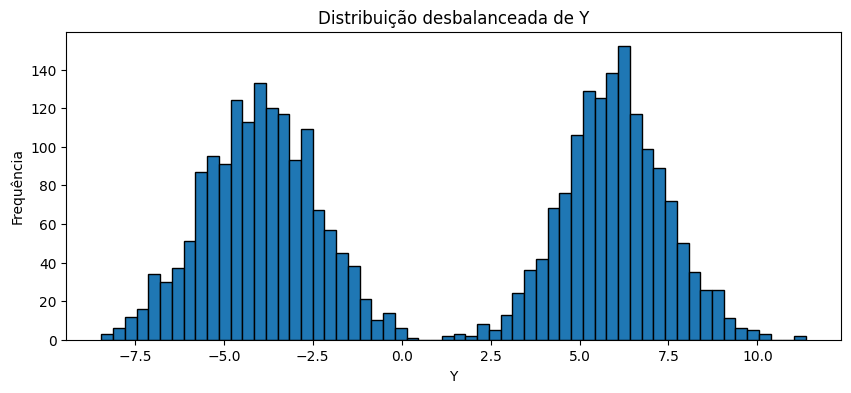

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(y, bins=60, edgecolor="black")
plt.title("Distribuição desbalanceada de Y")
plt.xlabel("Y")
plt.ylabel("Frequência")
plt.show()

In [ ]:
y = df['y'].values
X = df.drop(columns=['y']).values

In [ ]:
ih_scores_before = instance_hardness_regression(X, y)

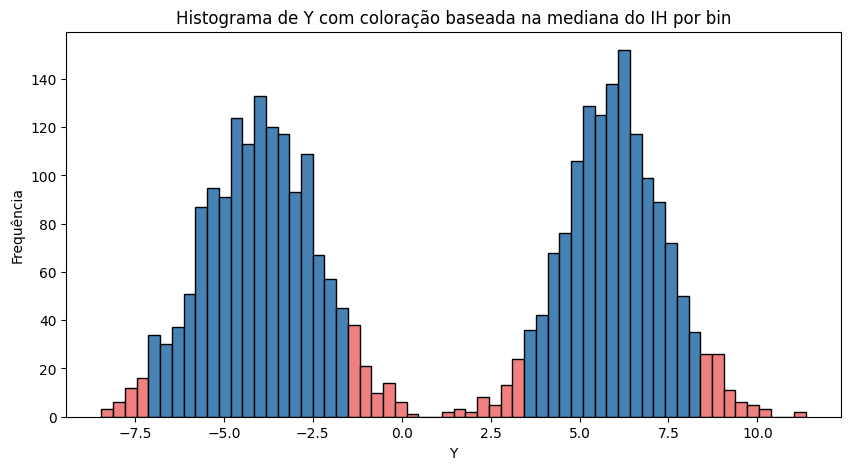

In [ ]:
ys = y
ihs = ih_scores_before

bins = 60

counts, bin_edges = np.histogram(ys, bins=bins)

global_threshold  = np.quantile(ihs, 0.8)

plt.figure(figsize=(10,5))

colors = []

bin_medians = []


for i in range(len(bin_edges)-1):
    left = bin_edges[i]
    right = bin_edges[i+1]

    mask = (ys >= left) & (ys < right)
    ih_bin = ihs[mask]

    if len(ih_bin) > 0:
        med_bin = np.median(ih_bin)
    else:
        med_bin = 0

    bin_medians.append(med_bin)

    if med_bin > global_threshold :
        colors.append("lightcoral")
    else:
        colors.append("steelblue")


for i in range(len(counts)):
    plt.bar(
        (bin_edges[i] + bin_edges[i+1]) / 2,
        counts[i],
        width=(bin_edges[i+1] - bin_edges[i]),
        color=colors[i],
        edgecolor="black"
    )

plt.title("Histograma de Y com coloração baseada na mediana do IH por bin")
plt.xlabel("Y")
plt.ylabel("Frequência")

plt.show()

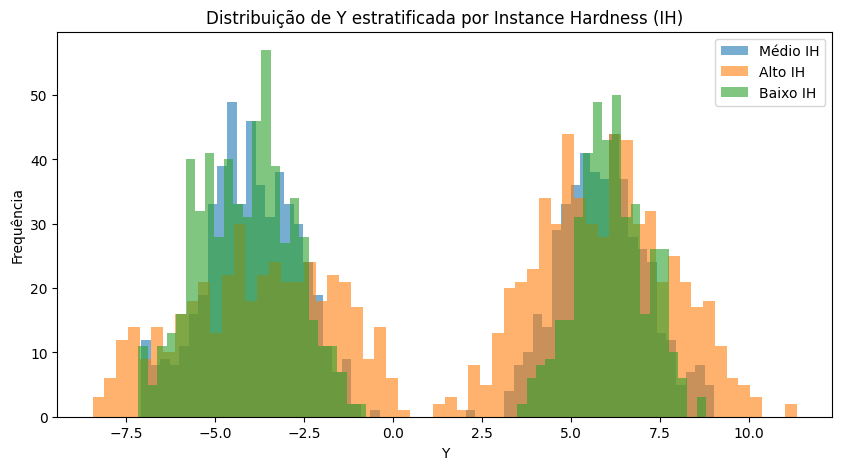

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_plot = pd.DataFrame({"y": y, "ih": ih_scores_before})

df_plot["ih_cat"] = pd.qcut(df_plot["ih"], q=3, labels=["Baixo IH", "Médio IH", "Alto IH"])

"""
primeiro terço → Baixo IH

segundo terço → Médio IH

terceiro terço → Alto IH
"""
plt.figure(figsize=(10,5))
for label in df_plot["ih_cat"].unique():
    subset = df_plot[df_plot["ih_cat"] == label]
    plt.hist(subset["y"], bins=60, alpha=0.6, label=label)

plt.legend()
plt.xlabel("Y")
plt.ylabel("Frequência")
plt.title("Distribuição de Y estratificada por Instance Hardness (IH)")
plt.show()


Aplicando o RO IH

In [ ]:
def instance_hardness_regression_ro(X, y, models=models_pool, distance='l1', n_splits=5, logs=False, gamma_fixo = False, fator_divisao_gamma = 1):
    n = len(y)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    if gamma_fixo:
      gamma = 1
    else:
      ### Justamente o que diz no artigo, que é a media do target elevado a 2
      gamma = np.mean(y**2) / fator_divisao_gamma #### Gamma menor -> Maior sensibilidade a erros, deixando o valor final de IG mais proximo de 1 ( Por padrão é np.mean(y**2))

    preds_pool = np.zeros((n, len(models)))

    ### Cross-validation ###
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        if logs:
          print(f"Iniciando fold {fold_idx}/{n_splits}...")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]

        df_train = pd.concat([
            pd.DataFrame(X_train),
            pd.Series(y_train, name="target")
        ], axis=1)

        df_train = apply_ro_ih(df_train, "target")
        X_train = df_train.drop(columns=["target"])
        y_train = df_train["target"].values


        ### ADICIONAR OS TIPOS DE BALANCEAMENTO NO X_TRAIN AQUI
        for j, model in enumerate(models):
            if logs:
              print(f"Treinando modelo {j+1}/{len(models)}: {type(model).__name__} ...")
            clone_model = type(model)(**model.get_params())
            clone_model.fit(X_train, y_train)
            preds_pool[test_idx, j] = clone_model.predict(X_test)

    if distance == 'l1':
        dists = np.abs(y.reshape(-1, 1) - preds_pool)
    elif distance == 'l2':
        dists = (y.reshape(-1, 1) - preds_pool)**2
    else:
        raise ValueError("Use 'l1' ou 'l2'.")

    exp_term = np.exp(-dists / gamma)
    ih_values = 1 - np.mean(exp_term, axis=1) ### Isso equivale a divisão por |L|

    return ih_values

In [ ]:
y = df['y'].values
X = df.drop(columns=['y']).values

In [ ]:
ih_scores_after = instance_hardness_regression_ro(X, y)

r_index: 100%|##########| 1/1 [00:00<00:00, 10230.01it/s]


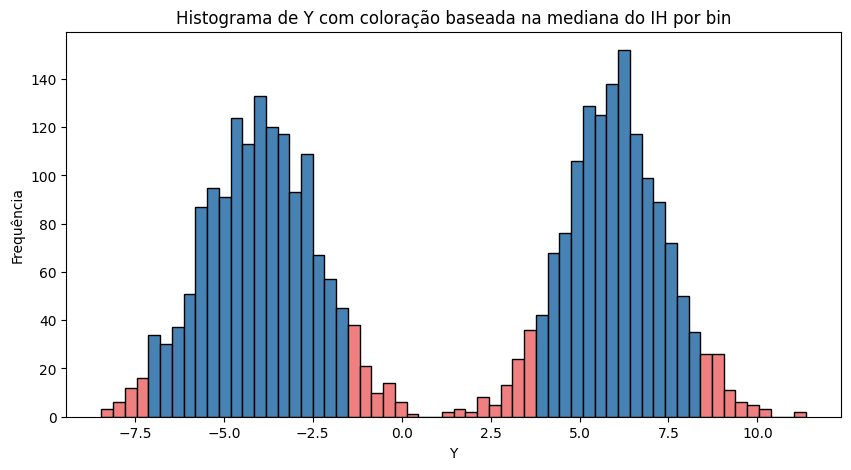

In [ ]:
ys = y
ihs = ih_scores_after

bins = 60

counts, bin_edges = np.histogram(ys, bins=bins)

global_threshold  = np.quantile(ihs, 0.8)

plt.figure(figsize=(10,5))

colors = []

bin_medians = []


for i in range(len(bin_edges)-1):
    left = bin_edges[i]
    right = bin_edges[i+1]

    mask = (ys >= left) & (ys < right)
    ih_bin = ihs[mask]

    if len(ih_bin) > 0:
        med_bin = np.median(ih_bin)
    else:
        med_bin = 0

    bin_medians.append(med_bin)

    if med_bin > global_threshold :
        colors.append("lightcoral")
    else:
        colors.append("steelblue")


for i in range(len(counts)):
    plt.bar(
        (bin_edges[i] + bin_edges[i+1]) / 2,
        counts[i],
        width=(bin_edges[i+1] - bin_edges[i]),
        color=colors[i],
        edgecolor="black"
    )

plt.title("Histograma de Y com coloração baseada na mediana do IH por bin")
plt.xlabel("Y")
plt.ylabel("Frequência")

plt.show()

Realmente por essa visualização eles não deveriam mudar, pq apesar de ter aumentando o número de valores, continuam sendo os mais dificeis

# Comparando as metricas pro balanced mse


In [ ]:
ro = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_RO_07_repeat.csv')
gn = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_GN_07_repeated.csv')

# Padronizar nomes das versões
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'RO': 'GN',
    'Hardness-RO': 'Hardness-GN'  # caso tenha esse nome
})

# Unir tudo
df = pd.concat([ro, gn], ignore_index=True)

In [ ]:
df

,Dataset,Repeticao,Fold,Model,Versao,MSE,MAE,y_pred,y_true
0,a1,1,1,SVR,Original,5.048297e+02,14.816346,"[11.897459888206152, 11.897901030020094, 9.040...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
1,a1,1,1,SVR,RO,3.821721e+02,15.382543,"[25.09981044248248, 25.103028808546057, 18.054...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
2,a1,1,1,SVR,Hardness-RO,5.557329e+02,15.562868,"[9.108573610229046, 9.109582690739652, 6.92041...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
3,a1,1,1,NNET,Original,8.927546e+05,311.047890,"[15.37254147076657, 18.135845331609488, 145.97...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
4,a1,1,1,NNET,RO,4.610535e+06,809.815675,"[-1.3922728151799608, -1.071719947555647, 304....","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
...,...,...,...,...,...,...,...,...,...
8695,wine,2,5,RF,GN,4.521584e-01,0.497503,"[5.386870264697864, 5.14140510491529, 4.908945...","[5.0, 5.0, 4.0, 6.0, 5.0, 5.0, 5.0, 6.0, 5.0, ..."
8696,wine,2,5,RF,Hardness-GN,4.604597e-01,0.501209,"[5.42, 5.19, 5.61, 5.77, 5.32, 5.27, 5.31, 5.6...","[5.0, 5.0, 4.0, 6.0, 5.0, 5.0, 5.0, 6.0, 5.0, ..."
8697,wine,2,5,BAGGING,Original,4.183603e-01,0.460893,"[5.0, 4.9, 5.0, 5.3, 5.2, 5.1, 5.3, 5.6, 5.2, ...","[5.0, 5.0, 4.0, 6.0, 5.0, 5.0, 5.0, 6.0, 5.0, ..."
8698,wine,2,5,BAGGING,GN,5.097583e-01,0.528312,"[5.501511582927354, 5.3, 4.811112176757154, 5....","[5.0, 5.0, 4.0, 6.0, 5.0, 5.0, 5.0, 6.0, 5.0, ..."


In [ ]:
import numpy as np

def bMSE(y_true, y_pred, n_bins=10):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # definir bins uniformes no espaço de y
    bins = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    bin_ids = np.digitize(y_true, bins) - 1

    bin_mses = []

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue  # ignora bins vazios
        mse_bin = np.mean((y_true[mask] - y_pred[mask]) ** 2)
        bin_mses.append(mse_bin)

    return np.mean(bin_mses)

def bMAE(y_true, y_pred, n_bins=10):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.linspace(y_true.min(), y_true.max(), n_bins + 1)
    bin_ids = np.digitize(y_true, bins) - 1

    bin_maes = []

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        mae_bin = np.mean(np.abs(y_true[mask] - y_pred[mask]))
        bin_maes.append(mae_bin)

    return np.mean(bin_maes)


In [ ]:
import ast

df['y_true_list'] = df['y_true'].apply(ast.literal_eval)
df['y_pred_list'] = df['y_pred'].apply(ast.literal_eval)



In [ ]:
df['bMSE'] = df.apply(
    lambda row: bMSE(row['y_true_list'], row['y_pred_list'], n_bins=10),
    axis=1
)

df['bMAE'] = df.apply(
    lambda row: bMAE(row['y_true_list'], row['y_pred_list'], n_bins=10),
    axis=1
)

In [ ]:
df.head()

,Dataset,Repeticao,Fold,Model,Versao,MSE,MAE,y_pred,y_true,y_true_list,y_pred_list,bMSE,bMAE
0,a1,1,1,SVR,Original,5.048297e+02,14.816346,"[11.897459888206152, 11.897901030020094, 9.040...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[11.897459888206152, 11.897901030020094, 9.040...",9.048165e+02,24.485972
1,a1,1,1,SVR,RO,3.821721e+02,15.382543,"[25.09981044248248, 25.103028808546057, 18.054...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[25.09981044248248, 25.103028808546057, 18.054...",4.990776e+02,18.994770
2,a1,1,1,SVR,Hardness-RO,5.557329e+02,15.562868,"[9.108573610229046, 9.109582690739652, 6.92041...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[9.108573610229046, 9.109582690739652, 6.92041...",1.019051e+03,26.284172
3,a1,1,1,NNET,Original,8.927546e+05,311.047890,"[15.37254147076657, 18.135845331609488, 145.97...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[15.37254147076657, 18.135845331609488, 145.97...",2.764963e+05,145.605637
4,a1,1,1,NNET,RO,4.610535e+06,809.815675,"[-1.3922728151799608, -1.071719947555647, 304....","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...","[-1.3922728151799608, -1.071719947555647, 304....",1.349237e+06,336.923023


In [ ]:
# Função para decidir o vencedor de cada Dataset+Model
def vencedor(grupo):
    linha_min = grupo.loc[grupo["bMAE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
    })

# Calcular vencedor por dataset + modelo
vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)

# Somar as vitórias por modelo
tabela_final = vitorias.groupby("Model").sum().reset_index()

linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()]
})

# Concatenar no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)

/tmp/ipython-input-1876508325.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)


In [ ]:
tabela_final

,Model,Original,RO,Hardness-RO,GN,Hardness-GN
0,BAGGING,5,13,5,5,1
1,NNET,6,8,8,4,3
2,RF,10,8,6,3,2
3,SVR,4,13,1,9,2
4,XGB,9,7,6,4,3
5,Total,34,49,26,25,11


In [ ]:
# Função para decidir o vencedor de cada Dataset+Model
def vencedor(grupo):
    linha_min = grupo.loc[grupo["bMSE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
    })

# Calcular vencedor por dataset + modelo
vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)

# Somar as vitórias por modelo
tabela_final = vitorias.groupby("Model").sum().reset_index()

linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()]
})

# Concatenar no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)

/tmp/ipython-input-4120416791.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df.groupby(["Dataset", "Model"]).apply(vencedor)


In [ ]:
tabela_final

,Model,Original,RO,Hardness-RO,GN,Hardness-GN
0,BAGGING,5,10,3,7,4
1,NNET,2,9,12,4,2
2,RF,11,6,5,4,3
3,SVR,2,12,2,11,2
4,XGB,9,5,7,4,4
5,Total,29,42,29,30,15


## Descontinuado

In [ ]:
import pandas as pd
import numpy as np
import ast

# =========================
# 1. Ler os CSVs
# =========================
ro = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_RO_07_repeat.csv')
gn = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_GN_07_repeated.csv')

# =========================
# 2. Padronizar nomes das versões
# =========================
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'RO': 'GN',
    'Hardness-RO': 'Hardness-GN'
})

# =========================
# 3. Converter y_pred e y_true (string -> lista)
# =========================
for df in [ro, gn]:
    df['y_pred'] = df['y_pred'].apply(ast.literal_eval)
    df['y_true'] = df['y_true'].apply(ast.literal_eval)

# =========================
# 4. Selecionar colunas relevantes
# =========================
cols = ['Dataset', 'Model', 'Versao', 'y_pred', 'y_true']

df_tmp = pd.concat(
    [ro[cols], gn[cols]],
    ignore_index=True
)

# =========================
# 5. Concatenar os vetores por Dataset / Model / Versao
# =========================
df_concatenado = (
    df_tmp
    .groupby(['Dataset', 'Model', 'Versao'], as_index=False)
    .agg(
        y_pred=('y_pred', lambda x: np.concatenate(x.to_list())),
        y_true=('y_true', lambda x: np.concatenate(x.to_list()))
    )
)

# =========================
# 6. Checagem de consistência (opcional, mas recomendado)
# =========================
df_concatenado['len_pred'] = df_concatenado['y_pred'].apply(len)
df_concatenado['len_true'] = df_concatenado['y_true'].apply(len)

assert (df_concatenado['len_pred'] == df_concatenado['len_true']).all()

# (opcional) remover colunas auxiliares
df_concatenado = df_concatenado.drop(columns=['len_pred', 'len_true'])



In [ ]:
df_concatenado.head(10)

,Dataset,Model,Versao,y_pred,y_true
0,a1,BAGGING,GN,"[60.82206595840099, 48.6166245035023, 70.78254...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
1,a1,BAGGING,Hardness-GN,"[12.98166786929784, 34.59503843223926, 13.8200...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
2,a1,BAGGING,Hardness-RO,"[29.250000000000007, 38.89, 50.29999999999999,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
3,a1,BAGGING,Original,"[29.1, 36.33, 45.57000000000001, 27.4899999999...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
4,a1,BAGGING,RO,"[51.09, 52.9, 31.799999999999994, 45.95, 3.389...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
5,a1,NNET,GN,"[21.637976951764987, 23.77544769751635, 246.84...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
6,a1,NNET,Hardness-GN,"[7.267407479034452, 7.103411013747634, -57.536...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
7,a1,NNET,Hardness-RO,"[-0.841622723555251, -0.7567866568162633, 453....","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
8,a1,NNET,Original,"[15.37254147076657, 18.135845331609488, 145.97...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."
9,a1,NNET,RO,"[-1.3922728151799608, -1.071719947555647, 304....","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,..."


In [ ]:
import numpy as np
import pandas as pd
from smogn import phi, phi_ctrl_pts

# =========================
# Garantir que y_true e y_pred são np.array
# =========================
df_concatenado["y_true"] = df_concatenado["y_true"].apply(np.asarray)
df_concatenado["y_pred"] = df_concatenado["y_pred"].apply(np.asarray)

# =========================
# Função auxiliar para calcular Weighted MAE
# =========================
def mae_phi_weighted(y_true, y_pred, coef=1.5):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # calcula ctrl_pts para o y_true específico
    y_series = pd.Series(y_true)
    ctrl_pts = phi_ctrl_pts(y=y_series, method="auto", xtrm_type="both", coef=coef)

    # calcula phi
    phi_values = np.asarray(phi(y_series, ctrl_pts=ctrl_pts))

    # weighted MAE
    weighted_abs_error = phi_values * np.abs(y_true - y_pred)
    return np.sqrt(np.mean(weighted_abs_error))

# =========================
# Itera sobre o df_concatenado e calcula Weighted MAE
# =========================
weighted_mae_list = []

for idx, row in df_concatenado.iterrows():
    weighted_mae = mae_phi_weighted(row["y_true"], row["y_pred"])
    weighted_mae_list.append(weighted_mae)

# =========================
# Adiciona a nova coluna
# =========================
df_concatenado["Weighted MAE"] = weighted_mae_list

# =========================
# Resultado
# =========================
print(df_concatenado.head())


  Dataset    Model       Versao  \
0      a1  BAGGING           GN   
1      a1  BAGGING  Hardness-GN   
2      a1  BAGGING  Hardness-RO   
3      a1  BAGGING     Original   
4      a1  BAGGING           RO   

                                              y_pred  \
0  [60.82206595840099, 48.6166245035023, 70.78254...   
1  [12.98166786929784, 34.59503843223926, 13.8200...   
2  [29.250000000000007, 38.89, 50.29999999999999,...   
3  [29.1, 36.33, 45.57000000000001, 27.4899999999...   
4  [51.09, 52.9, 31.799999999999994, 45.95, 3.389...   

                                              y_true  Weighted MAE  
0  [17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...      2.129990  
1  [17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...      2.245555  
2  [17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...      2.177911  
3  [17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...      2.187267  
4  [17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...      2.155432  


In [ ]:
df_concatenado.head(20)

,Dataset,Model,Versao,y_pred,y_true,Weighted MAE
0,a1,BAGGING,GN,"[60.82206595840099, 48.6166245035023, 70.78254...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",2.129990
1,a1,BAGGING,Hardness-GN,"[12.98166786929784, 34.59503843223926, 13.8200...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",2.245555
2,a1,BAGGING,Hardness-RO,"[29.250000000000007, 38.89, 50.29999999999999,...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",2.177911
3,a1,BAGGING,Original,"[29.1, 36.33, 45.57000000000001, 27.4899999999...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",2.187267
4,a1,BAGGING,RO,"[51.09, 52.9, 31.799999999999994, 45.95, 3.389...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",2.155432
5,a1,NNET,GN,"[21.637976951764987, 23.77544769751635, 246.84...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",4.787655
6,a1,NNET,Hardness-GN,"[7.267407479034452, 7.103411013747634, -57.536...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",4.142177
7,a1,NNET,Hardness-RO,"[-0.841622723555251, -0.7567866568162633, 453....","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",4.151063
8,a1,NNET,Original,"[15.37254147076657, 18.135845331609488, 145.97...","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",3.844773
9,a1,NNET,RO,"[-1.3922728151799608, -1.071719947555647, 304....","[17.0, 69.9, 46.2, 50.6, 0.0, 13.0, 3.4, 29.5,...",5.029078


In [ ]:
import pandas as pd

# =========================
# Função para identificar vencedor por grupo Dataset + Model
# =========================
def vencedor(grupo):
    # Linha com menor Weighted MAE
    linha_min = grupo.loc[grupo["Weighted MAE"].idxmin()]
    vencedor = linha_min["Versao"]

    return pd.Series({
        'Original': int(vencedor == 'Original'),
        'RO': int(vencedor == 'RO'),
        'Hardness-RO': int(vencedor == 'Hardness-RO'),
        'GN': int(vencedor == 'GN'),
        'Hardness-GN': int(vencedor == 'Hardness-GN'),
    })

# =========================
# Calcular vencedor por Dataset + Model
# =========================
vitorias = df_concatenado.groupby(["Dataset", "Model"]).apply(vencedor)

# =========================
# Somar as vitórias por modelo
# =========================
tabela_final = vitorias.groupby("Model").sum().reset_index()

# =========================
# Adicionar linha Total
# =========================
linha_total = pd.DataFrame({
    "Model": ["Total"],
    "Original": [tabela_final["Original"].sum()],
    "RO": [tabela_final["RO"].sum()],
    "Hardness-RO": [tabela_final["Hardness-RO"].sum()],
    "GN": [tabela_final["GN"].sum()],
    "Hardness-GN": [tabela_final["Hardness-GN"].sum()]
})

# Concatenar Total no final
tabela_final = pd.concat([tabela_final, linha_total], ignore_index=True)

# =========================
# Resultado final
# =========================
print(tabela_final)


     Model  Original  RO  Hardness-RO  GN  Hardness-GN
0  BAGGING         3  15            2   9            0
1     NNET         5  10            4   6            4
2       RF         4  14            1  10            0
3      SVR         0   7            0  22            0
4      XGB         9   5            5   9            1
5    Total        21  51           12  56            5


/tmp/ipython-input-2290622233.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vitorias = df_concatenado.groupby(["Dataset", "Model"]).apply(vencedor)


Ganhou pq ambos usam phi, vamos testar utilizandoi IH

In [ ]:
tabela_final

,Model,Original,RO,Hardness-RO,GN,Hardness-GN
0,BAGGING,3,15,2,9,0
1,NNET,5,10,4,6,4
2,RF,4,14,1,10,0
3,SVR,0,7,0,22,0
4,XGB,9,5,5,9,1
5,Total,21,51,12,56,5


# Juntando tudo em uma tabela

In [ ]:
import pandas as pd

# Carregar datasets
ro = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_RO_07_repeat.csv')
gn = pd.read_csv('/content/drive/MyDrive/TCC/comparacao_final_GN_07_repeated.csv')

# Padronizar nomes das versões
ro['Versao'] = ro['Versao'].replace({
    'Original': 'Original',
    'RO': 'RO',
    'Hardness-RO': 'Hardness-RO'
})

gn['Versao'] = gn['Versao'].replace({
    'Original': 'Original',
    'RO': 'GN',
    'Hardness-RO': 'Hardness-GN'  # caso venha errado
})

# Unir tudo
df = pd.concat([ro, gn], ignore_index=True)

# Calcular a média do MAE por Dataset + Model + Versao
df_media = (
    df
    .groupby(['Model', 'Dataset', 'Versao'])['MAE']
    .mean()
    .reset_index()
)

# Criar uma tabela por modelo
tabelas_por_modelo = {}

for model in df_media['Model'].unique():
    tabela = (
        df_media[df_media['Model'] == model]
        .pivot(index='Dataset', columns='Versao', values='MAE')
        .reset_index()
    )

    # Garantir ordem das colunas
    ordem = ['Dataset', 'Original', 'RO', 'Hardness-RO', 'GN', 'Hardness-GN']
    tabela = tabela.reindex(columns=ordem)

    tabelas_por_modelo[model] = tabela


In [ ]:
tabelas_por_modelo['BAGGING']


Versao,Dataset,Original,RO,Hardness-RO,GN,Hardness-GN
0,a1,12.160385,12.701449,12.314399,15.302117,12.288802
1,a2,7.440384,8.070637,7.127744,9.188208,7.115563
2,a3,5.308396,5.677702,4.934984,6.389532,4.975145
3,a7,3.262304,3.313365,3.160042,4.072223,3.136497
4,abalone,1.722002,1.785981,1.723479,2.099069,1.759879
5,acceleration,0.592753,0.575997,0.579632,0.672913,0.658715
6,airfoild,1560.742914,1300.052046,1637.901056,2732.407893,11532.205438
7,analcatdata_apnea3,394.652556,430.857222,390.567333,426.307282,507.110768
8,available_power,2.238321,1.974326,2.111673,3.034670,4.986967
9,boston,2.586520,2.568537,2.577320,2.808380,2.880325


In [ ]:
tabelas_por_modelo['NNET']

Versao,Dataset,Original,RO,Hardness-RO,GN,Hardness-GN
0,a1,282.608819,384.176189,317.442029,432.038607,261.425448
1,a2,290.388674,353.703922,356.169416,410.650847,288.532632
2,a3,279.080986,390.857678,294.638677,655.574471,309.106109
3,a7,276.790649,366.277301,326.268745,532.617468,316.217893
4,abalone,2.324735,2.619521,2.274426,2.915678,2.280537
5,acceleration,7.544270,9.547649,8.220511,8.662201,8.249406
6,airfoild,37245.655784,46617.368835,37423.617105,65402.797974,38998.958864
7,analcatdata_apnea3,452.233922,425.609308,378.272141,662.233756,567.496799
8,available_power,15.716851,16.289047,14.030989,16.636579,14.934249
9,boston,128.865742,60.842977,20.947438,114.955002,35.564417


In [ ]:
tabelas_por_modelo['RF']

Versao,Dataset,Original,RO,Hardness-RO,GN,Hardness-GN
0,a1,11.515071,11.972114,11.699547,14.663884,12.215243
1,a2,7.039150,7.800228,7.035090,9.220924,6.996556
2,a3,5.043726,5.420615,4.939124,6.167989,4.895218
3,a7,3.164443,3.209533,2.960776,4.173381,2.976816
4,abalone,1.645620,1.700737,1.641658,2.019802,1.696493
5,acceleration,0.553144,0.547816,0.546825,0.640731,0.625715
6,airfoild,1417.119723,1201.064101,1447.145457,2444.773024,11335.056787
7,analcatdata_apnea3,388.043267,428.578833,383.720767,410.368647,504.666088
8,available_power,2.074123,1.908200,1.901146,2.805061,4.846863
9,boston,2.432764,2.452975,2.436316,2.685557,2.675099


In [ ]:
tabelas_por_modelo['SVR']

Versao,Dataset,Original,RO,Hardness-RO,GN,Hardness-GN
0,a1,14.380785,16.027205,14.476596,25.205083,14.898024
1,a2,6.713906,7.751408,6.729380,12.857643,7.139962
2,a3,4.044368,4.670265,4.094499,6.241048,4.158568
3,a7,2.445175,2.776152,2.521224,3.463545,2.611099
4,abalone,1.874463,2.041862,1.891865,2.653517,1.981226
5,acceleration,2.083978,2.728419,2.043713,4.068443,2.072524
6,airfoild,15945.968501,16865.815754,15961.636376,22789.638054,16303.424814
7,analcatdata_apnea3,830.683261,832.957992,830.982396,880.349389,831.554833
8,available_power,19.345560,17.811946,19.390302,19.083640,22.007614
9,boston,6.471715,6.784533,6.451189,9.079625,6.486565


In [ ]:
tabelas_por_modelo['XGB']

Versao,Dataset,Original,RO,Hardness-RO,GN,Hardness-GN
0,a1,12.675543,12.290946,12.794672,14.669918,13.180042
1,a2,7.560880,7.651167,7.626136,9.592427,7.197670
2,a3,5.467114,5.384880,5.318754,6.060899,5.314107
3,a7,2.959119,3.185181,3.034306,3.750002,3.090593
4,abalone,1.724465,1.767613,1.698475,2.058637,1.768004
5,acceleration,0.475578,0.490244,0.493350,0.597727,0.593416
6,airfoild,1425.721867,1253.611643,1499.371864,2857.150332,10285.314242
7,analcatdata_apnea3,448.821672,453.017729,438.804739,479.747269,542.586411
8,available_power,1.551826,1.705019,1.631705,2.483726,4.165537
9,boston,2.503389,2.555536,2.490018,2.699818,2.773697
